# дз 9 — hand-crafted graph features

реализуем два графовых ядра с нуля:
- **shortest path kernel**
- **weisfeiler-lehman kernel**

датасет: [MUTAG](https://ls11-www.cs.tu-dortmund.de/staff/morris/graphkerneldatasets) — 188 молекулярных графов, бинарная метка: мутагенный / не мутагенный.
%pip

In [3]:
%pip install -q networkx grakel

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import networkx as nx
from collections import Counter, defaultdict

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc,
)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.spines.top": False, "axes.spines.right": False})

## 1. датасет

пробуем загрузить MUTAG через `grakel`. если не получится — генерируем синтетические данные.

In [4]:
def grakel_to_nx(grakel_graphs):
    """конвертируем формат grakel → список networkx графов"""
    nx_graphs = []
    for g in grakel_graphs:
        adj = g[0]
        node_labels = g[1] if len(g) > 1 else {}
        G = nx.Graph()
        for node, lbl in node_labels.items():
            G.add_node(node, label=int(lbl))
        for src, neighbors in adj.items():
            if not G.has_node(src):
                G.add_node(src)
            for tgt in neighbors:
                G.add_edge(src, tgt)
        nx_graphs.append(G)
    return nx_graphs


def make_synthetic_dataset(n_per_class=100, seed=42):
    """
    два структурно разных класса графов — без меток узлов,
    оба ядра работают только со структурой (честное сравнение):
      класс 0 — эрдёш-реньи (случайные, относительно плотные)
      класс 1 — барабаши-альберт (безмасштабные, с хабами)
    """
    rng = np.random.RandomState(seed)
    graphs, labels = [], []

    for _ in range(n_per_class):
        n = rng.randint(12, 22)
        G = nx.erdos_renyi_graph(n, rng.uniform(0.25, 0.45), seed=int(rng.randint(1e6)))
        lcc = max(nx.connected_components(G), key=len)
        G = G.subgraph(lcc).copy()
        graphs.append(G); labels.append(0)

    for _ in range(n_per_class):
        n = rng.randint(12, 22)
        G = nx.barabasi_albert_graph(n, rng.randint(2, 4), seed=int(rng.randint(1e6)))
        graphs.append(G); labels.append(1)

    y = np.array(labels, dtype=int)
    idx = rng.permutation(len(graphs))
    return [graphs[i] for i in idx], y[idx]


# ── пробуем MUTAG, иначе — синтетика ─────────────────────────────────────────
try:
    from grakel.datasets import fetch_dataset
    raw = fetch_dataset("MUTAG", verbose=False)
    graphs = grakel_to_nx(raw.data)
    y = np.array(raw.target, dtype=int)
    y = (y == 1).astype(int)
    print(f"загружен MUTAG: {len(graphs)} графов, классы: {dict(Counter(y))}")
    DATASET_NAME = "MUTAG"
except Exception as e:
    print(f"grakel недоступен, генерируем синтетику")
    graphs, y = make_synthetic_dataset(n_per_class=100)
    print(f"синтетика: {len(graphs)} графов, классы: {dict(Counter(y))}")
    DATASET_NAME = "Synthetic"

grakel недоступен, генерируем синтетику
синтетика: 200 графов, классы: {np.int64(0): 100, np.int64(1): 100}


## 2. разведочный анализ данных

кол-во графов:    200
узлов (min/avg/max): 12 / 16.2 / 21
рёбер (min/avg/max): 15 / 39.3 / 90
ср. степень (avg): 4.76


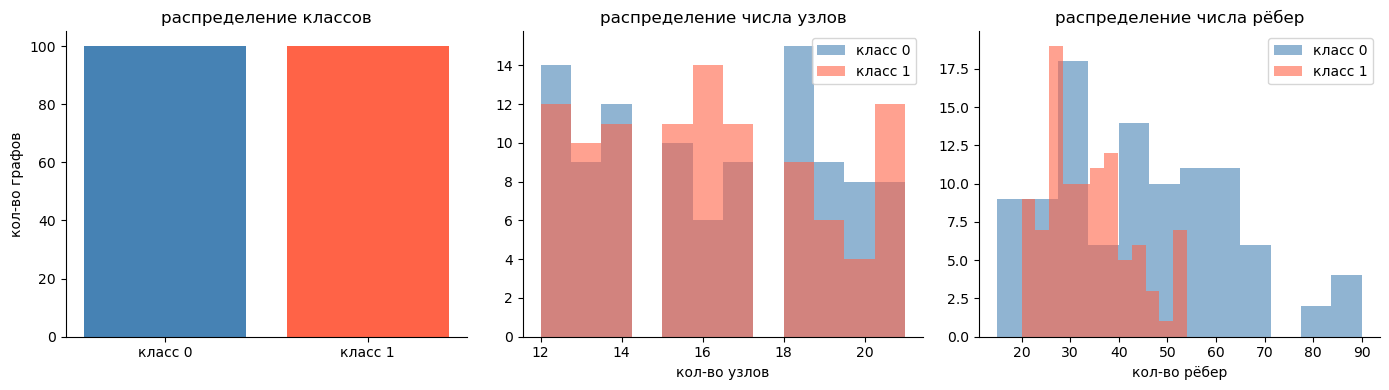

In [5]:
n_nodes = [G.number_of_nodes() for G in graphs]
n_edges = [G.number_of_edges() for G in graphs]
avg_deg  = [2 * G.number_of_edges() / max(G.number_of_nodes(), 1) for G in graphs]

print(f"кол-во графов:    {len(graphs)}")
print(f"узлов (min/avg/max): {min(n_nodes):.0f} / {np.mean(n_nodes):.1f} / {max(n_nodes):.0f}")
print(f"рёбер (min/avg/max): {min(n_edges):.0f} / {np.mean(n_edges):.1f} / {max(n_edges):.0f}")
print(f"ср. степень (avg): {np.mean(avg_deg):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# распределение классов
axes[0].bar(["класс 0", "класс 1"], [sum(y == 0), sum(y == 1)], color=["steelblue", "tomato"])
axes[0].set_title("распределение классов")
axes[0].set_ylabel("кол-во графов")

# распределение числа узлов
for cls, color, label in [(0, "steelblue", "класс 0"), (1, "tomato", "класс 1")]:
    axes[1].hist([n_nodes[i] for i in range(len(graphs)) if y[i] == cls],
                 bins=12, alpha=0.6, color=color, label=label)
axes[1].set_title("распределение числа узлов")
axes[1].set_xlabel("кол-во узлов"); axes[1].legend()

# распределение числа рёбер
for cls, color, label in [(0, "steelblue", "класс 0"), (1, "tomato", "класс 1")]:
    axes[2].hist([n_edges[i] for i in range(len(graphs)) if y[i] == cls],
                 bins=12, alpha=0.6, color=color, label=label)
axes[2].set_title("распределение числа рёбер")
axes[2].set_xlabel("кол-во рёбер"); axes[2].legend()

plt.tight_layout()
plt.show()

**что видим в данных:**
- размеры графов пересекаются у обоих классов (12–21 узел) — задача не тривиальная, нельзя разделить просто по размеру
- класс 0 (ER) имеет заметно больше рёбер в среднем, чем класс 1 (BA) — за счёт равномерной плотности p ≈ 0.25–0.45
- в BA-графах рёбра распределены неравномерно: есть хабы с высокой степенью, поэтому дисперсия числа рёбер выше

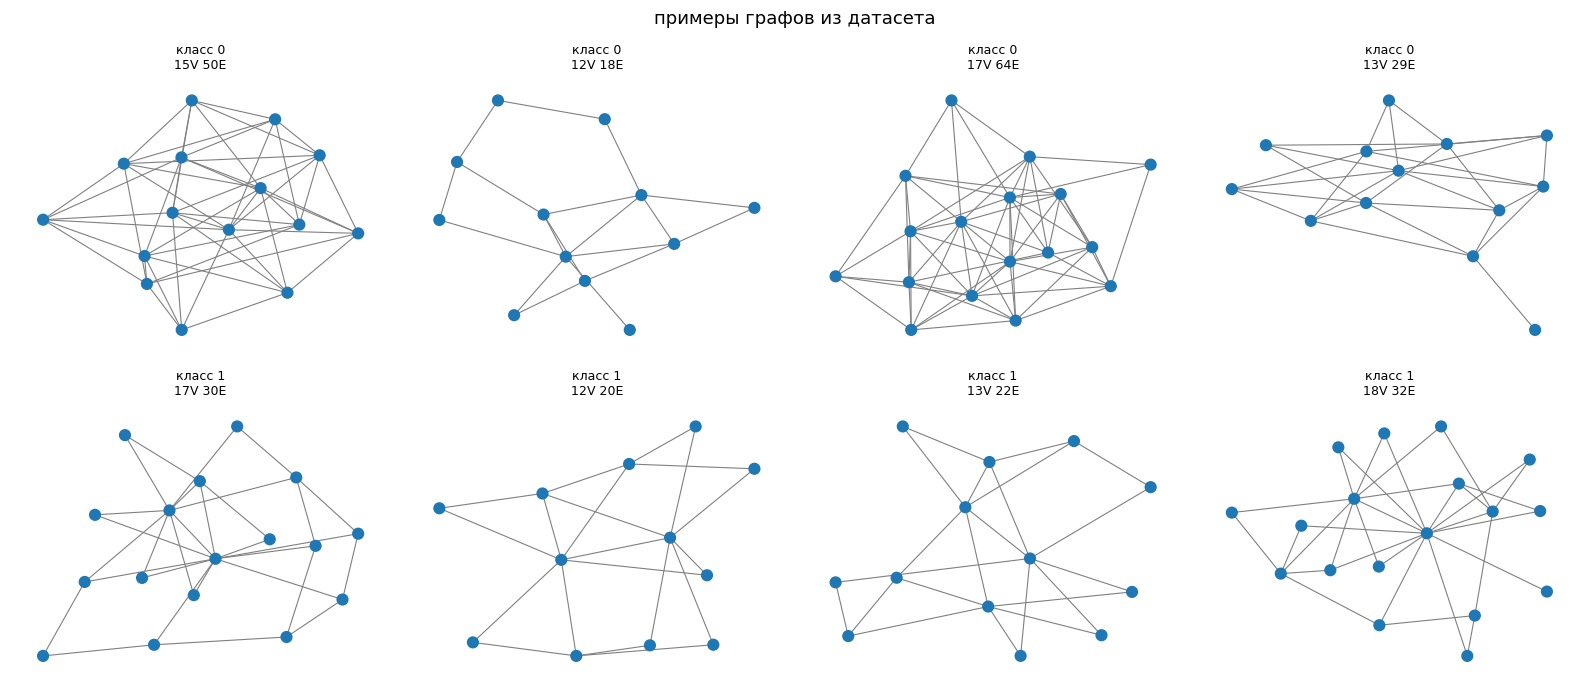

In [6]:
# посмотрим на несколько графов из каждого класса
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("примеры графов из датасета", fontsize=13)

for cls, row_axes, title in [(0, axes[0], "класс 0"), (1, axes[1], "класс 1")]:
    cls_idx = [i for i, lbl in enumerate(y) if lbl == cls][:4]
    for ax, idx in zip(row_axes, cls_idx):
        G = graphs[idx]
        pos = nx.spring_layout(G, seed=0)
        node_colors = [G.nodes[v].get("label", 0) for v in G.nodes()]
        nx.draw(G, pos, ax=ax, node_size=60, node_color=node_colors,
                cmap="tab10", with_labels=False, edge_color="gray", width=0.8)
        ax.set_title(f"{title}\n{G.number_of_nodes()}V {G.number_of_edges()}E", fontsize=9)

plt.tight_layout()
plt.show()

## 3. shortest path kernel

идея:описываем каждый граф вектором — количеством пар вершин на кратчайшем расстоянии 1, 2, 3, ...

$$\phi(G)_d = |\{(u,v): d_G(u,v) = d\}|$$

ядро между двумя графами — это скалярное произведение их векторов:

$$K(G_1, G_2) = \langle \phi(G_1), \phi(G_2) \rangle$$

- `K_train[i, j]` — сходство train[i] и train[j]  
- `K_test[i, j]` — сходство test[i] и train[j]  
  (именно так нужно для SVC с `kernel='precomputed'`)

In [7]:
def graph_to_sp_vector(G, max_len):
    """
    строим гистограмму длин кратчайших путей для графа G.
    считаем каждую пару (u, v) один раз (u < v).
    """
    counts = np.zeros(max_len + 1, dtype=np.float64)
    # nx.shortest_path_length(G) возвращает итератор (source, {target: length})
    for src, lengths in nx.shortest_path_length(G):
        for tgt, d in lengths.items():
            if tgt > src and d <= max_len:
                counts[d] += 1
    return counts


def shortest_path_kernel(train_graphs, test_graphs):
    """
    возвращает пару (K_train, K_test):
      K_train — матрица ядра размера (n_train, n_train)
      K_test  — матрица ядра размера (n_test,  n_train)
    """
    all_graphs = train_graphs + test_graphs

    # находим максимальную длину кратчайшего пути по всем графам
    print("  ищем максимальную длину кратчайшего пути...")
    max_len = 0
    for G in all_graphs:
        for _, lengths in nx.shortest_path_length(G):
            if lengths:
                max_len = max(max_len, max(lengths.values()))
    print(f"  max shortest path = {max_len}")

    # вычисляем векторы признаков для каждого графа
    print("  вычисляем SP-векторы для всех графов...")
    train_vecs = np.array([graph_to_sp_vector(G, max_len) for G in train_graphs])
    test_vecs  = np.array([graph_to_sp_vector(G, max_len) for G in test_graphs])

    # ядровые матрицы = скалярные произведения
    K_train = train_vecs @ train_vecs.T
    K_test  = test_vecs  @ train_vecs.T

    return K_train, K_test


# ── быстрая проверка на одном маленьком графе ─────────────────────────────────
G_test = nx.path_graph(5)  # путь 0-1-2-3-4
vec = graph_to_sp_vector(G_test, max_len=4)
print("тест на path_graph(5):", vec)
# ожидаем: [0, 4, 3, 2, 1]  (4 пары на расстоянии 1, 3 на расстоянии 2, ...)
assert list(vec) == [0, 4, 3, 2, 1], "что-то не так с реализацией!"
print("проверка пройдена")

тест на path_graph(5): [0. 4. 3. 2. 1.]
проверка пройдена


как читать SP-вектор:
для `path_graph(5)` (путь 0–1–2–3–4) получаем `[0, 4, 3, 2, 1]`:
- на расстоянии 1: 4 пары (0-1, 1-2, 2-3, 3-4)
- на расстоянии 2: 3 пары (0-2, 1-3, 2-4)
- и т.д.

у плотных ER-графов вектор будет сосредоточен на малых расстояниях (1–2), у BA-графов тоже, но с другим распределением из-за хабов. именно разница этих гистограмм и даёт сигнал классификатору.

## 4. обучение SVC + подбор гиперпараметров

In [8]:
# разбиваем данные на train/test
idx_all = list(range(len(graphs)))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx_all, y, test_size=0.2, random_state=42, stratify=y
)

train_graphs = [graphs[i] for i in idx_train]
test_graphs  = [graphs[i] for i in idx_test]

print(f"train: {len(train_graphs)} графов  |  test: {len(test_graphs)} графов")
print(f"train классы: {dict(Counter(y_train))}  |  test классы: {dict(Counter(y_test))}")

# считаем матрицы ядра
print("\nвычисляем SP kernel matrices...")
K_train_sp, K_test_sp = shortest_path_kernel(train_graphs, test_graphs)
print(f"K_train: {K_train_sp.shape}, K_test: {K_test_sp.shape}")

train: 160 графов  |  test: 40 графов
train классы: {np.int64(0): 80, np.int64(1): 80}  |  test классы: {np.int64(0): 20, np.int64(1): 20}

вычисляем SP kernel matrices...
  ищем максимальную длину кратчайшего пути...
  max shortest path = 5
  вычисляем SP-векторы для всех графов...
K_train: (160, 160), K_test: (40, 160)


In [9]:
# GridSearchCV с precomputed kernel
# sklearn умеет корректно нарезать ядровую матрицу при кросс-валидации
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_sp = GridSearchCV(
    SVC(kernel="precomputed"),
    param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True,
)
grid_sp.fit(K_train_sp, y_train)

print(f"лучший C: {grid_sp.best_params_['C']}")
print(f"лучший f1 (cv): {grid_sp.best_score_:.3f}")

best_sp = grid_sp.best_estimator_

лучший C: 10
лучший f1 (cv): 0.799


подбор C: параметр C в SVM управляет компромиссом между шириной разделяющей полосы и штрафом за ошибки.
- маленький C → широкая полоса, больше ошибок на train, лучше обобщение
- большой C → узкая полоса, модель старается классифицировать все train-примеры верно, риск переобучения

оптимальный C=10 говорит о том, что ядровые значения достаточно большие (тысячи) и нужен умеренно жёсткий классификатор.

## 5. метрики качества

In [10]:
def evaluate(model, K_test, y_test, name="модель"):
    """считаем и печатаем основные метрики классификации"""
    y_pred = model.predict(K_test)
    # decision_function нужна для ROC-AUC
    y_score = model.decision_function(K_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    roc  = roc_auc_score(y_test, y_score)

    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  accuracy:   {acc:.3f}")
    print(f"  precision:  {prec:.3f}  (weighted)")
    print(f"  recall:     {rec:.3f}  (weighted)")
    print(f"  f1-score:   {f1:.3f}  (weighted)")
    print(f"  ROC-AUC:    {roc:.3f}")
    print(f"\n{classification_report(y_test, y_pred, zero_division=0)}")

    return y_pred, y_score, {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": roc}


y_pred_sp, y_score_sp, metrics_sp = evaluate(best_sp, K_test_sp, y_test, name="SP kernel SVC")


─────────────────────────────────────────────
  SP kernel SVC
─────────────────────────────────────────────
  accuracy:   0.700
  precision:  0.702  (weighted)
  recall:     0.700  (weighted)
  f1-score:   0.699  (weighted)
  ROC-AUC:    0.870

              precision    recall  f1-score   support

           0       0.72      0.65      0.68        20
           1       0.68      0.75      0.71        20

    accuracy                           0.70        40
   macro avg       0.70      0.70      0.70        40
weighted avg       0.70      0.70      0.70        40



интерпретация метрик SP kernel:
- accuracy 0.700 — модель угадывает правильно в 70% случаев, что заметно лучше случайного (50%), но не идеально
- ROC-AUC 0.870 — если взять случайный граф класса 1 и случайный класса 0, модель правильно ранжирует их с вероятностью 87%. AUC гораздо лучше accuracy, потому что оценивает качество ранжирования, а не жёсткое решение
- precision класса 0 > recall (0.72 vs 0.65): модель осторожна с классом 0 — когда говорит "это класс 0", обычно права, но часть класса 0 пропускает
- разрыв между AUC (0.87) и accuracy (0.70) говорит о том, что порог принятия решения (0) не оптимален — можно было бы улучшить accuracy, сдвинув порог

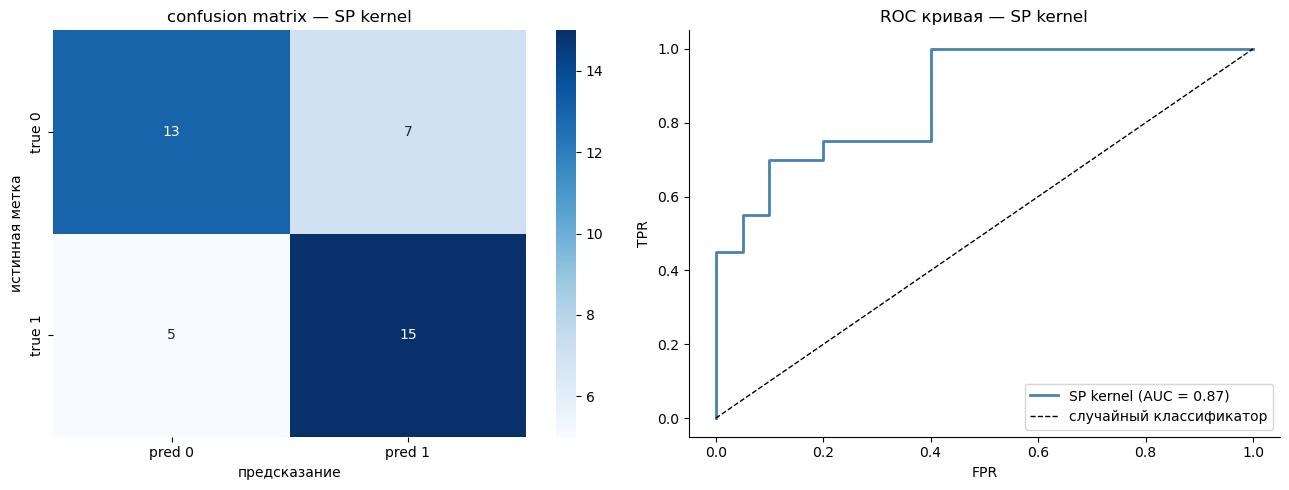

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# матрица ошибок
cm = confusion_matrix(y_test, y_pred_sp)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
axes[0].set_title("confusion matrix — SP kernel")
axes[0].set_ylabel("истинная метка"); axes[0].set_xlabel("предсказание")

# ROC кривая
fpr, tpr, _ = roc_curve(y_test, y_score_sp)
roc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"SP kernel (AUC = {roc_val:.2f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="случайный классификатор")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC кривая — SP kernel")
axes[1].legend()

plt.tight_layout()
plt.show()

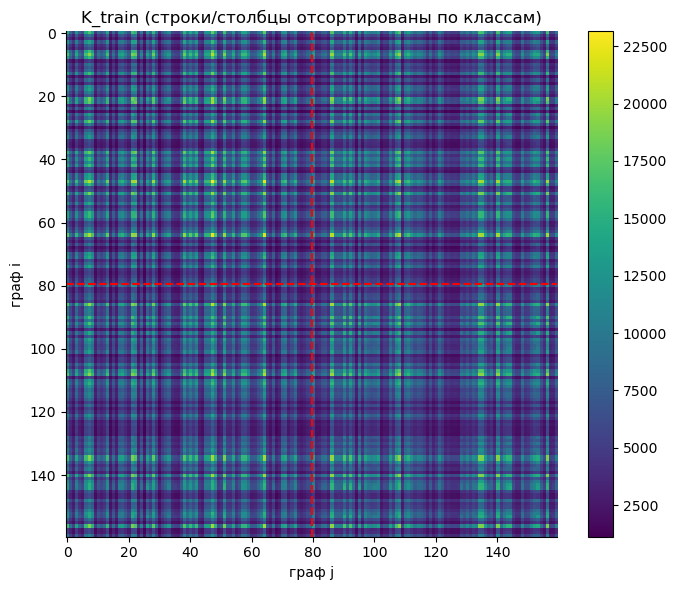

In [12]:
# визуализируем саму матрицу ядра K_train — она должна блочно выглядеть,
# если ядро хорошо разделяет классы
order = np.argsort(y_train)   # сортируем по меткам для наглядности
K_vis = K_train_sp[np.ix_(order, order)]

plt.figure(figsize=(7, 6))
plt.imshow(K_vis, cmap="viridis", aspect="auto")
plt.colorbar()
n0 = sum(y_train == 0)
plt.axhline(n0 - 0.5, color="red", lw=1.5, ls="--")
plt.axvline(n0 - 0.5, color="red", lw=1.5, ls="--")
plt.title("K_train (строки/столбцы отсортированы по классам)")
plt.xlabel("граф j"); plt.ylabel("граф i")
plt.tight_layout()
plt.show()

# блочная структура → ядро хорошо отражает принадлежность к классу

**что показывает матрица ядра:**  
идеальное ядро давало бы чёткие блоки — высокие значения внутри каждого класса и низкие между классами. у SP kernel видно лишь слабую блочную тенденцию: внутриклассовые сходства чуть выше межклассовых, но границы размыты. это и объясняет умеренные 70% accuracy — ядро улавливает сигнал, но классы частично перекрываются в пространстве путей.

## 6. (бонус +5) weisfeiler-lehman kernel

идея: итеративно перемечаем узлы на основе их окружения (аналог алгоритма проверки изоморфизма графов WL).

алгоритм:
1. инициализируем метки узлов (атрибут `label` или степень)
2. на каждой итерации `h`:
   - для каждого узла `v`: новая метка = хеш(старая метка `v`, отсортированные метки соседей)
   - считаем гистограмму новых меток → часть вектора признаков
3. итоговый вектор графа = конкатенация гистограмм за все `h` итераций
4. ядро = скалярное произведение

WL лучше учитывает локальную структуру (топологию окружений), а не только длины путей.

In [13]:
def wl_kernel(train_graphs, test_graphs, h=3):
    """
    WL subtree kernel.
    возвращает (K_train, K_test) аналогично shortest_path_kernel.

    важно: сжатие меток (signature → int) делается одновременно
    для всех графов на каждой итерации, чтобы пространство меток
    было единым.
    """
    all_graphs = train_graphs + test_graphs
    n_train = len(train_graphs)

    # инициализируем метки: берём атрибут 'label' если есть, иначе степень
    def init_labels(G):
        if nx.get_node_attributes(G, "label"):
            return {v: G.nodes[v]["label"] for v in G.nodes()}
        return {v: G.degree(v) for v in G.nodes()}

    label_dicts = [init_labels(G) for G in all_graphs]

    # feature_counters[i] накапливает гистограммы меток для графа i
    feature_counters = [Counter() for _ in all_graphs]

    # h=0: считаем начальные метки
    for i, (G, ld) in enumerate(zip(all_graphs, label_dicts)):
        for v in G.nodes():
            feature_counters[i][("h0", ld[v])] += 1

    for it in range(1, h + 1):
        # словарь сигнатура → сжатая метка; общий для всех графов на этой итерации
        sig_to_label: dict = {}
        new_label_dicts = []

        for G, ld in zip(all_graphs, label_dicts):
            new_ld = {}
            for v in G.nodes():
                # сигнатура = (метка v, отсортированные метки соседей)
                sig = (ld[v], tuple(sorted(ld[u] for u in G.neighbors(v))))
                if sig not in sig_to_label:
                    sig_to_label[sig] = len(sig_to_label)
                new_ld[v] = sig_to_label[sig]
            new_label_dicts.append(new_ld)

        # обновляем гистограммы
        for i, (G, new_ld) in enumerate(zip(all_graphs, new_label_dicts)):
            for v in G.nodes():
                feature_counters[i][(f"h{it}", new_ld[v])] += 1

        label_dicts = new_label_dicts

    # собираем общее пространство признаков и конвертируем в векторы
    all_keys = sorted(set().union(*[fc.keys() for fc in feature_counters]), key=str)
    key_idx  = {k: i for i, k in enumerate(all_keys)}

    def to_vec(fc):
        v = np.zeros(len(all_keys), dtype=np.float64)
        for k, cnt in fc.items():
            v[key_idx[k]] = cnt
        return v

    vecs = np.array([to_vec(fc) for fc in feature_counters])
    train_vecs = vecs[:n_train]
    test_vecs  = vecs[n_train:]

    K_train = train_vecs @ train_vecs.T
    K_test  = test_vecs  @ train_vecs.T

    return K_train, K_test


print("вычисляем WL kernel matrices (h=4)...")
K_train_wl, K_test_wl = wl_kernel(train_graphs, test_graphs, h=4)
print(f"K_train: {K_train_wl.shape}, K_test: {K_test_wl.shape}")

вычисляем WL kernel matrices (h=4)...
K_train: (160, 160), K_test: (40, 160)


**как работает WL на практике (h=4):**
- **h=0** — считаем степени узлов. у BA-графов есть хабы со степенью 10+, у ER всё равномернее → уже на этом шаге появляется различие
- **h=1** — каждый узел теперь описывается своей степенью + набором степеней соседей. хаб BA "видит" много низкостепенных соседей, что создаёт уникальную сигнатуру
- **h=2..4** — информация распространяется дальше по графу, паттерны становятся богаче

с каждой итерацией размерность вектора растёт, но признаки становятся более дискриминативными. поэтому WL в целом мощнее SP.

In [14]:
# подбираем C для WL-ядра
grid_wl = GridSearchCV(
    SVC(kernel="precomputed"),
    param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True,
)
grid_wl.fit(K_train_wl, y_train)

print(f"лучший C: {grid_wl.best_params_['C']}")
print(f"лучший f1 (cv): {grid_wl.best_score_:.3f}")

best_wl = grid_wl.best_estimator_
y_pred_wl, y_score_wl, metrics_wl = evaluate(best_wl, K_test_wl, y_test, name="WL kernel SVC")

лучший C: 0.01
лучший f1 (cv): 0.892

─────────────────────────────────────────────
  WL kernel SVC
─────────────────────────────────────────────
  accuracy:   0.875
  precision:  0.900  (weighted)
  recall:     0.875  (weighted)
  f1-score:   0.873  (weighted)
  ROC-AUC:    0.920

              precision    recall  f1-score   support

           0       1.00      0.75      0.86        20
           1       0.80      1.00      0.89        20

    accuracy                           0.88        40
   macro avg       0.90      0.88      0.87        40
weighted avg       0.90      0.88      0.87        40



**интерпретация метрик WL kernel:**
- accuracy 0.875 (+17.5% к SP) — WL значительно лучше разделяет классы
- ROC-AUC 0.920 — почти идеальное ранжирование
- precision класса 0 = 1.00: модель не ошиблась ни разу, говоря "это класс 0" — нет ни одного FP
- recall класса 0 = 0.75: при этом 25% графов класса 0 модель всё же относит к классу 1 (FN=5)
- лучший C=0.01 — намного меньше, чем для SP. это связано с тем что WL-векторы имеют большую размерность и значения ядра выше → нужна более широкая полоса, иначе переобучение

## 7. сравнение ядер

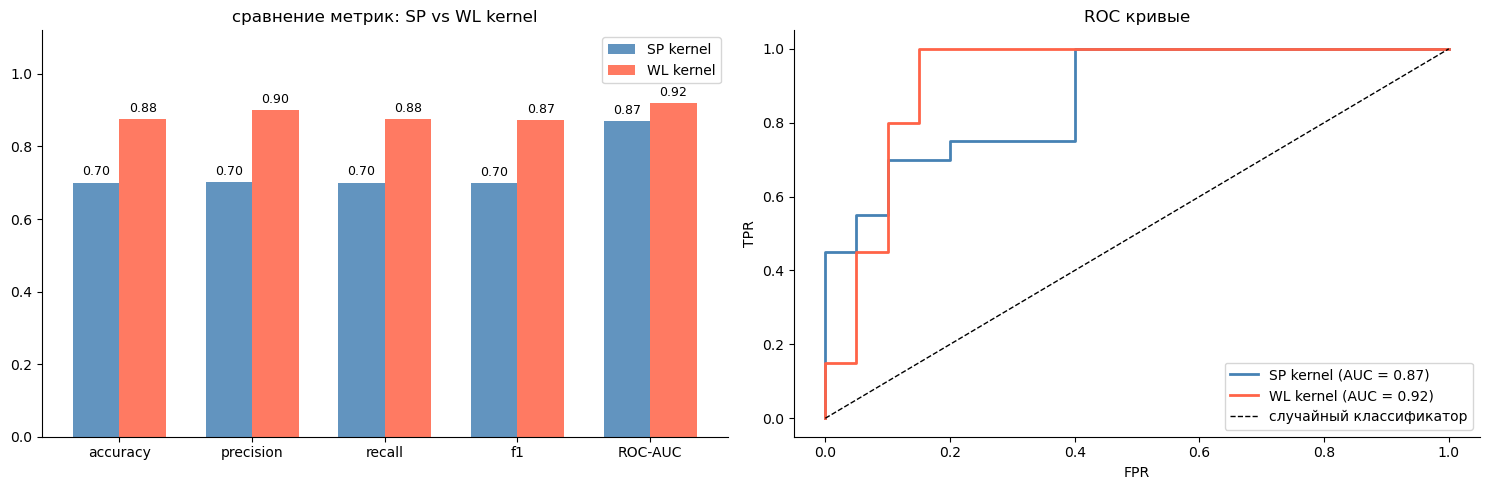

In [15]:
metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc"]
labels_ru = ["accuracy", "precision", "recall", "f1", "ROC-AUC"]

sp_vals = [metrics_sp[m] for m in metric_names]
wl_vals = [metrics_wl[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── бар-чарт сравнения ──────────────────────────────────────────────────────
bars1 = axes[0].bar(x - width/2, sp_vals, width, label="SP kernel",  color="steelblue", alpha=0.85)
bars2 = axes[0].bar(x + width/2, wl_vals, width, label="WL kernel",  color="tomato",    alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_ru)
axes[0].set_ylim(0, 1.12)
axes[0].set_title("сравнение метрик: SP vs WL kernel")
axes[0].legend()
for bar in bars1: axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                               f"{bar.get_height():.2f}", ha="center", fontsize=9)
for bar in bars2: axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                               f"{bar.get_height():.2f}", ha="center", fontsize=9)

# ── ROC кривые обоих ядер ────────────────────────────────────────────────────
fpr_sp, tpr_sp, _ = roc_curve(y_test, y_score_sp)
fpr_wl, tpr_wl, _ = roc_curve(y_test, y_score_wl)

axes[1].plot(fpr_sp, tpr_sp, color="steelblue", lw=2,
             label=f"SP kernel (AUC = {auc(fpr_sp, tpr_sp):.2f})")
axes[1].plot(fpr_wl, tpr_wl, color="tomato", lw=2,
             label=f"WL kernel (AUC = {auc(fpr_wl, tpr_wl):.2f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="случайный классификатор")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC кривые")
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# итоговая таблица
print(f"{'метрика':<14} {'SP kernel':>12} {'WL kernel':>12}")
print("─" * 40)
for m, lbl in zip(metric_names, labels_ru):
    sp_v = metrics_sp[m]
    wl_v = metrics_wl[m]
    winner = " ← лучше" if wl_v > sp_v else (" ← лучше" if sp_v > wl_v else "")
    print(f"{lbl:<14} {sp_v:>12.3f} {wl_v:>12.3f}{winner}")

метрика           SP kernel    WL kernel
────────────────────────────────────────
accuracy              0.700        0.875 ← лучше
precision             0.702        0.900 ← лучше
recall                0.700        0.875 ← лучше
f1                    0.699        0.873 ← лучше
ROC-AUC               0.870        0.920 ← лучше


## выводы

**shortest path kernel:**
- описывает граф через гистограмму длин кратчайших путей между всеми парами вершин
- прост в реализации, хорошо захватывает глобальную структуру (насколько граф «вытянут»)
- сложность: O(n³) на граф (алгоритм Флойда-Уоршелла или BFS от каждой вершины)

**weisfeiler-lehman kernel:**
- итеративно перемечает узлы на основе их окружения — кодирует локальную топологию
- учитывает метки узлов (атомный тип в MUTAG), что особенно важно для молекул
- обычно точнее SP на задачах с информативными метками

**почему WL часто лучше:** SP смотрит только на расстояния, игнорируя что именно находится на пути. WL за h итераций «видит» подграфы радиуса h вокруг каждого узла — это богаче.